# Regresión lineal

## Regresión - ¿para qué se usa?

El análisis de regresión tiene múltiples usos y se encuentra en casi todas las áreas y disciplinas. Nos permite:

- Establecer relaciones entre dos o más variables
- Predecir qué valor tomará una variable en función de otra(s)

Además de establecer relaciones entre variables, nos da indicios acerca de cómo es esa relación, es decir de cuánto el cambio de una variable independiente incide en la variable dependiente.

A partir de modelar la relación entre variables (partiendo de una muestra, de datos históricos, de observaciones) es posible predecir ciertos resultados que permiten tomar decisiones informadas

## Regresión

Habiendo estudiado la teoría de las variables aleatorias (por ejemplo cantidad de hijos) y analizado propiedades de las mismas (su esperanza, su varianza…), ahora nos ocuparemos de modelar la relación entre estas variables.

¿Cómo?

Buscando el modelo que mejor represente esa relación, y que nos permita estimar ciertos parámetros que la caractericen correctamente

## Regresión

Comenzaremos con el modelo de regresión lineal, que es relativamente simple y cuya fórmula matemática es sencilla de interpretar.

Ecuación de la regresión lineal simple:

$$ Y = \beta_0 + \beta_1 X $$

donde $\beta_1$ es la **pendiente** y $\beta_0$ la **constante** (ordenada al origen).

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

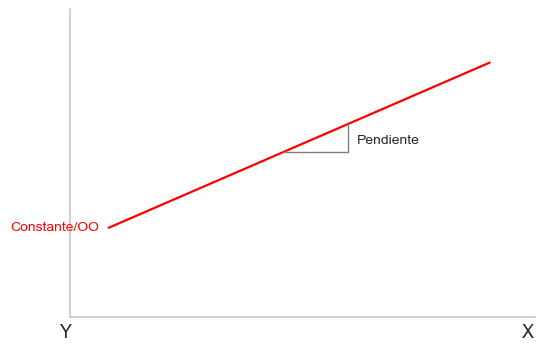

In [ ]:
# Esquema básico de una recta de regresión lineal: constante (ordenada al origen) y pendiente
fig, ax = plt.subplots(figsize=(6, 4))

xr = np.array([0.6, 6.5])
b0_e, b1_e = 1.3, 0.5
ax.plot(xr, b0_e + b1_e * xr, color="red", lw=1.6)          # la recta

# constante / ordenada al origen (donde la recta "arranca" a la izquierda)
ax.text(0.45, b0_e + b1_e * 0.6, "Constante/OO", color="red",
        ha="right", va="center", fontsize=10)

# marca de pendiente (escalón)
x0 = 3.3; dx = 1.0
y0 = b0_e + b1_e * x0
ax.plot([x0, x0 + dx], [y0, y0], color="gray", lw=1)
ax.plot([x0 + dx, x0 + dx], [y0, b0_e + b1_e * (x0 + dx)], color="gray", lw=1)
ax.text(x0 + dx + 0.15, y0 + 0.15, "Pendiente", fontsize=10)

# ejes al estilo de la lámina
ax.set_xlim(0, 7.2); ax.set_ylim(0, 5.5)
ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks([]); ax.set_yticks([])
ax.text(7.0, -0.35, "X", fontsize=13)
ax.text(-0.15, -0.35, "Y", fontsize=13)
plt.show()

## Regresión lineal

Supuesto teórico del modelo lineal: la relación entre variables es lineal.

¿Cómo podemos indagar si este supuesto tiene sentido en relación a datos específicos?

Una buena primera aproximación es hacer un análisis de correlación entre las variables antes de estimar el modelo lineal

## Librerías

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## Regresión lineal - asociación entre variables y correlación

Asociación entre variables cuantitativas: enfoque gráfico (gráficos de dispersión) y enfoque numérico.

### Covarianza

Covarianza: medida que indica la asociación lineal entre dos variables aleatorias X e Y:

$$ \operatorname{Cov}(X, Y) = E\big((X_i - E(X))(Y_i - E(Y))\big) $$

Se analiza si ambas tienen variación conjunta. Variabilidad de cada variable con respecto a su valor esperado.

- $\operatorname{Cov}(X, Y) > 0$ &nbsp; relación positiva
- $\operatorname{Cov}(X, Y) < 0$ &nbsp; relación negativa
- $\operatorname{Cov}(X, Y) = 0$ &nbsp; ninguna relación

Es un promedio donde cada individuo aporta el producto de la distancia de su variable X respecto a la media por la de su variable Y respecto a la media. Si estas co-variaciones tienen siempre la misma orientación, hablamos de una asociación de tipo lineal.

La covarianza está en unidades de medida que dependen de cada variable. Por eso se utiliza frecuentemente el coeficiente de correlación.

**Limitaciones de la covarianza…**

1. La covarianza puede tomar cualquier valor entre $-\infty$ y $+\infty$ (covarianza de 5 puede ser más que de 1200).
2. La covarianza depende del nivel de medición de las variables (la covarianza entre altura en cm y peso en kg es distinta que la covarianza entre pies y libras cuando todas las mediciones se hacen sobre los mismos individuos).

## Regresión lineal - asociación entre variables y correlación

### Índice de correlación lineal de Pearson

Coeficiente de correlación: considera la varianza y la divide por el producto de los desvíos estándar de las variables.

$$ \rho(X, Y) = \frac{\operatorname{cov}(X, Y)}{\sigma_X \, \sigma_Y} \qquad \sigma_X = \sqrt{\operatorname{var}(X)} \quad \sigma_Y = \sqrt{\operatorname{var}(Y)} $$

Es un valor que va de -1 a 1 e indica tanto la fuerza como la dirección de la relación entre dos variables.

$$ -1 \le \rho(X, Y) \le 1 $$

Es independiente de las unidades de medida de las variables. El coeficiente de correlación de Pearson solo nos sirve para indicar asociaciones de tipo lineal entre variables cuantitativas y esa es su única utilidad. Un par de variables pueden tener un coeficiente de Pearson 0 y sin embargo tener otro tipo de asociación no lineal.

## Regresión lineal - asociación entre variables y correlación

Dependiendo de cuál es la recta (en caso de que la haya) que mejor representa nuestros datos obtendremos distintos valores de R.

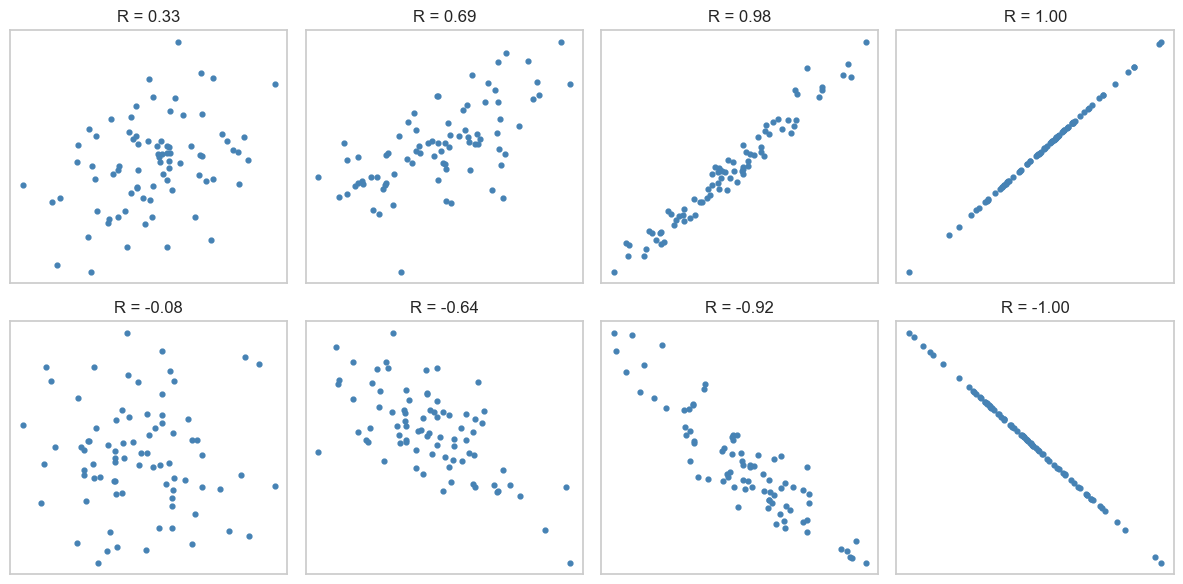

In [3]:
# Distintos valores del coeficiente de correlación (R): simulamos pares (X, Y)
# con correlaciones objetivo y los graficamos.
from numpy.random import default_rng
rng = default_rng(7)

def datos_con_corr(r, n=80):
    x = rng.normal(size=n)
    e = rng.normal(size=n)
    y = r * x + np.sqrt(max(1 - r**2, 0)) * e
    return x, y

corrs = [0.33, 0.69, 0.98, 1.00, -0.08, -0.64, -0.92, -1.00]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, r in zip(axes.ravel(), corrs):
    x, y = datos_con_corr(r)
    ax.scatter(x, y, s=12, color="steelblue")
    ax.set_title(f"R = {r:.2f}")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
plt.show()

## Ejemplo práctico - experiencia laboral y salario

Ahora analicemos la relación entre dos variables específicas:

- Años de experiencia laboral
- Salario

¿Cómo creen que será esta relación?

In [4]:
salario = pd.read_csv("Salary_Data.csv")
salario.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


## Ejemplo práctico - experiencia laboral y salario

Estimamos la correlación entre ambas variables:

¿Cómo podemos ver gráficamente la relación lineal que estaría indicando este coeficiente?

In [5]:
x_var, y_var = "YearsExperience", "Salary"
correlacion_pearson = salario[x_var].corr(salario[y_var])
print(f"Coeficiente de correlación de Pearson: {correlacion_pearson:.3f}")

Coeficiente de correlación de Pearson: 0.978


## Ejemplo práctico - experiencia laboral y salario

2. Hacemos un gráfico de dispersión para ambas variables

Al observar la relación entre nivel de experiencia laboral (medida en años) y salario, esta se presupone lineal. Podemos representarla a través de una recta.

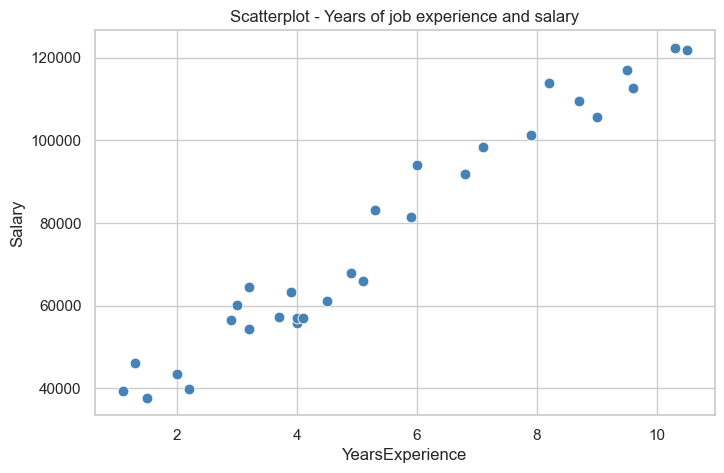

In [6]:
plt.figure()
sns.scatterplot(x=salario[x_var], y=salario[y_var], s=60, color="steelblue")
plt.title("Scatterplot - Years of job experience and salary")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

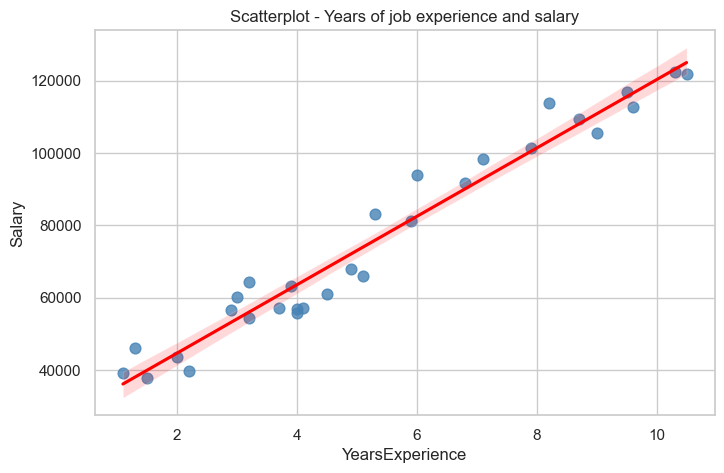

In [17]:
plt.figure()
sns.regplot(x=salario[x_var], y=salario[y_var],
            scatter_kws={"s": 60, "color": "steelblue"},
            line_kws={"color": "red"})
plt.title("Scatterplot - Years of job experience and salary")
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

## Regresión lineal simple - elementos de la ecuación

Este modelo nos permite estimar el valor de una variable (Y) en función de otra (X), donde tenemos un único regresor X:

$$ Y = \beta_0 + \beta_1 X_1 + \varepsilon $$

- $Y$ = variable dependiente, endógena o de interés.
- $X_1$ = variable independiente, explicativa o regresor.
- $\beta_0$ = constante. Es el valor estimado de Y cuando X = 0.
- $\beta_1$ = parámetro de una variable $X_1$.
- $\varepsilon$ = término de error: captura todo aquello no incluido en x.

## Regresión lineal simple - elementos de la ecuación

Años de experiencia y salario.

- $Y$ = variable dependiente, endógena o de interés. = salario
- $X_1$ = variable independiente, explicativa o regresor. = años de experiencia laboral
- $\beta_0$ = constante. Es el valor estimado de Y cuando X = 0 = salario cuando años de experiencia laboral = 0
- $\beta_1$ = parámetro de una variable (a veces se lo llama efecto marginal) = captura la medida del cambio en el salario por cada unidad adicional de años de experiencia

## Regresión lineal simple - estimación de parámetros

$$ \beta_0 = y - \beta_1 x_1 + \varepsilon \quad\longrightarrow\quad \text{Salario(años de experiencia}=0) $$

$$ \beta_1 = \text{Salario}(\text{años.exp}=n+1) - \text{Salario}(\text{años.exp}=n) $$

$$ \text{Salario}(n+1) = \beta_0 + \beta_1(n+1) + \varepsilon $$

$$ \text{Salario}(n) = \beta_0 + \beta_1 n + \varepsilon $$

$$ \beta_1 = \big(\beta_0 + \beta_1(n+1) + \varepsilon\big) - \big(\beta_0 + \beta_1 n + \varepsilon\big) $$

$\beta_1$ captura el cambio que produce una unidad adicional de experiencia en el salario (en promedio). Constituye el efecto marginal de la var. X sobre Y (por eso acompaña al regresor). Y también se lo suele definir como:

$$ \beta_j = \frac{\partial Y}{\partial X_j} \qquad j = 1,2,3\cdots k $$

$\beta_0$ y $\beta_1$ son parámetros poblacionales desconocidos. A través de distintos modelos, como por ejemplo la regresión lineal, buscamos estimarlos.

## Regresión lineal simple - estimación de parámetros

$\varepsilon$ representa el término de error de la regresión.

- En el error se incluye toda la variabilidad de Y que no se debe a X
- $\varepsilon$ en nuestro ejemplo = nivel educativo, industria/sector, género…

Nota: es importante que $\varepsilon$ cumpla con ciertas características en una regresión lineal. Más adelante las veremos.

## Regresión lineal simple - estimación de parámetros

$$ y = \beta_0 + \beta_1 x_1 + \varepsilon $$
$$ \text{Salario} = \beta_0 + \beta_1\,\text{Años.exp} + \varepsilon $$

¿Cuál es el problema de estimar el valor de Y a partir de una recta?

<figure style="text-align:center; margin:1em 0;">
  <img src="media/rls_valor_y_en_recta.png" width="380">
</figure>

## Regresión lineal simple - estimación de parámetros

Para este nivel dado de años de experiencia, no tenemos un único valor de salario.

Veamos las primeras observaciones de la base de datos…

In [18]:
salario.head(10)

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891
5,2.9,56642
6,3.0,60150
7,3.2,54445
8,3.2,64445
9,3.7,57189


## Regresión lineal simple - estimación de parámetros

La regresión estima un cierto valor salarial dado un nivel de experiencia laboral x. Pero en la muestra se observan datos que se encuentran tanto por encima como por debajo. Una forma de dar con la mejor predicción de Y es minimizar los residuos. MCC minimiza la distancia vertical ($\varepsilon$) al cuadrado entre las observaciones y la recta.

La diferencia entre el valor observado y el valor predicho se denomina RESIDUO.

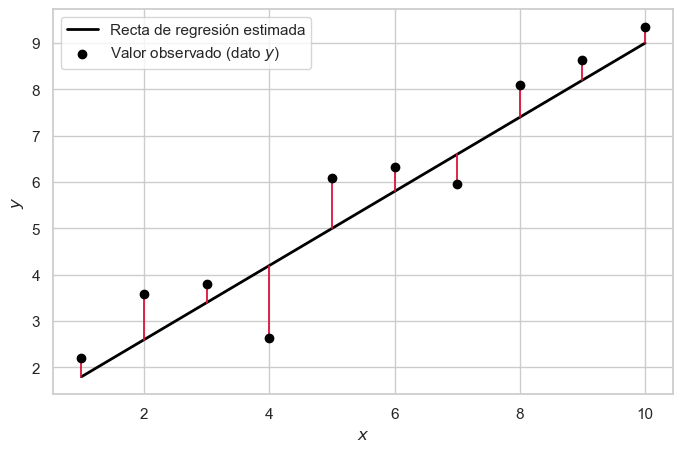

In [28]:
# Recta de regresión estimada y residuos (distancia vertical de cada dato a la recta)
rng = default_rng(1)
xd = np.arange(1, 11, dtype=float)
b0_c, b1_c = 1.0, 0.8
yd = b0_c + b1_c * xd + rng.normal(0, 1.2, size=xd.size)

plt.figure(figsize=(8, 5))
xs = np.linspace(xd.min(), xd.max(), 100)
plt.plot(xs, b0_c + b1_c * xs, color="black", lw=2, label="Recta de regresión estimada")
plt.scatter(xd, yd, color="black", zorder=3, label="Valor observado (dato $y$)")
for xi, yi in zip(xd, yd):
    plt.plot([xi, xi], [yi, b0_c + b1_c * xi], color="crimson", lw=1.3)
plt.xlabel("$x$"); plt.ylabel("$y$")
plt.legend()
plt.show()

## Regresión lineal simple - estimación de parámetros

Ej. caso 7 (años.exp=3.2 y salario=54445)

$\beta_0$ y $\beta_1$ fueron estimados, siendo:

- $\beta_0$ = 2.58
- $\beta_1$ = 9449

Cuando los años de experiencia = 3.2, el modelo estimaría:

$$ \text{Ingreso} = 2.58 + 9449 \cdot 3.2 + \varepsilon $$
$$ \text{Ingreso} = 30240 + \varepsilon $$
$$ \varepsilon = \text{ingreso} - \beta_0 + \beta_1 X_1 $$

¿Qué ocurre con $\varepsilon$?

$$ \varepsilon_i = +24205 $$

Se trata de un caso que presenta un salario por encima de la estimación para el nivel de experiencia que tiene (probablemente debido a otros factores explicativos que están en el error).

## Regresión lineal simple - estimación de parámetros

A través del método de MCC/OLS buscamos minimizar los residuos, es decir la distancia general del valor de cada observación con respecto al valor estimado por la recta. En particular lo que hace este método es elegir estimadores $\beta_0$ y $\beta_1$ que minimicen la suma de los errores elevados al cuadrado. Objetivo:

$$ \varepsilon_i \approx 0 \quad\text{y en consecuencia:}\quad \sum_{i=1}^{n} (\varepsilon_i)^2 = \varepsilon_1^2 + \varepsilon_2^2 + \dots + \varepsilon_n^2 $$

¿Por qué elevamos al cuadrado la suma de los residuos?

## Regresión lineal simple - estimación de parámetros

La suma de los cuadrados se eleva al cuadrado para evitar que los errores de las distintas observaciones se cancelen entre sí. Si la suma de los residuos al cuadrado tiene un valor pequeño, se supone que cada término de error también lo es, porque se trata de valores positivos en todos los casos.

MCC es una función que minimiza la suma de residuos al cuadrado considerando 2 variables = $\beta_0$ y $\beta_1$.

$$ \min_{\beta_0,\beta_1} \sum_{i=1}^{n} (\varepsilon_i)^2 = \min_{\beta_0,\beta_1} \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 x_i)^2 $$

$$ = \min_{\beta_0,\beta_1} \sum (Y_1 - \beta_0 - \beta_1 x_1)^2 + (Y_2 - \beta_0 - \beta_1 x_2)^2 + \dots + (Y_n - \beta_0 - \beta_1 x_n)^2 $$

A menos que $\rho(X,Y) = 1$ o $-1$, no existen parámetros $\beta_0$ y $\beta_1$ tal que $y_i - \beta_0 - \beta_i x_i = 0$ para cualquier i.

## Regresión lineal simple - estimación de parámetros

La minimización de la función MCC se hace derivando con respecto a $\beta_0$ y a $\beta_1$ (en cada caso la otra variable se deja constante).

$$ \frac{\partial \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 x_i)^2}{\partial \beta_0} = 0 $$

$$ \frac{\partial \sum_{i=1}^{n} (Y_i - \beta_0 - \beta_1 x_i)^2}{\partial \beta_1} = 0 $$

A partir de estas derivadas se obtienen las ecuaciones que nos permiten despejar las 2 incógnitas ($\beta_0$ y $\beta_1$):

$$ \beta_1 = \frac{\operatorname{cov}(x,y)}{\operatorname{var}(x)} $$

esta división permite eliminar el peso de la unidad de medida de x.

$\beta_0$ será la diferencia entre la estimación de Y y la parte explicada por el modelo:

$$ \beta_0 = \bar{Y} - \beta_1 \bar{X} $$

## Regresión lineal - lectura e inferencia del modelo

Los parámetros $\beta_0$ (ALFA) y $\beta_1$ (BETA) son poblacionales desconocidos y se estiman por mínimos cuadrados. Pero además de estimarlos, se deben plantear test de hipótesis para testear la significancia de los estimadores de beta y alfa y descartar que no sean nulos.

Para la evaluación de los estimadores sí necesitamos supuestos: que los errores siguen una distribución normal y con desvío sigma cuadrado y que esos errores son independientes entre sí. Si se cumplen, podemos definir un estadístico de prueba T que tiene distribución t de Student. ¿Por qué es importante todo esto? Porque si el estimador de BETA es 0, no podemos predecir. Ocurre algo idéntico en alfa, para saber si la ordenada al origen no es 0.

En la función OLS: el estimador de alfa es `const`, el estimador de beta acompaña a la variable independiente, y el estadístico t es = estimado / error estándar.

In [29]:
# Estimación por mínimos cuadrados (OLS)
X_sal = sm.add_constant(salario[x_var])
modelo_sal = sm.OLS(salario[y_var], X_sal).fit()

b0, b1 = modelo_sal.params
print(f"beta_0 (const) = {b0:,.2f}")
print(f"beta_1         = {b1:,.2f}")
print(modelo_sal.summary())

beta_0 (const) = 25,792.20
beta_1         = 9,449.96
                            OLS Regression Results                            
Dep. Variable:                 Salary   R-squared:                       0.957
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     622.5
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           1.14e-20
Time:                        18:27:45   Log-Likelihood:                -301.44
No. Observations:                  30   AIC:                             606.9
Df Residuals:                      28   BIC:                             609.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------

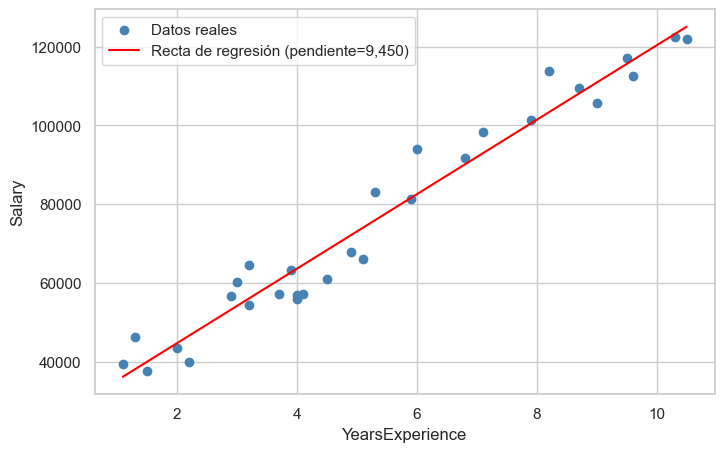

In [30]:
# Recta de regresión sobre la nube de puntos
plt.figure()
plt.scatter(salario[x_var], salario[y_var], color="steelblue", label="Datos reales")
x_grid = np.linspace(salario[x_var].min(), salario[x_var].max(), 100)
plt.plot(x_grid, b0 + b1 * x_grid, color="red", label=f"Recta de regresión (pendiente={b1:,.0f})")
plt.xlabel("YearsExperience"); plt.ylabel("Salary")
plt.legend()
plt.show()

## Regresión lineal simple - variable explicativa binaria

¿Se puede utilizar MCC (y un modelo lineal en general) ante la presencia de variables explicativas no numéricas? Por ejemplo: género.

Respuesta: sí.

Cuando un regresor X es una variable "indicadora" de la categoría hombre (por ejemplo), donde $I(\text{hombre}) = 1$ si se trata de un hombre e $I(\text{hombre})=0$ si se trata de una mujer, los $\beta$ miden la diferencia promedio entre la variable Y en cada categoría. Si Y=salario, $\beta$ capturaría la diferencia (positiva o negativa) producto de que una persona sea hombre. Si $\beta = 5000$, esto significa que los hombres ganan un salario de 5000 unidades más que las mujeres, en promedio.

$$ \text{Salario} = \beta_0 + \beta_1 I(\text{hombre}) + \varepsilon $$

$$ \text{Si } I(\text{hombre})=0 \Rightarrow \text{Salario} = \beta_0 + \varepsilon $$
$$ \text{Si } I(\text{hombre})=1 \Rightarrow \text{Salario} = \beta_0 + \beta_1 + \varepsilon $$
$$ \text{Ingreso}(I(\text{hombre})=1) - \text{Ingreso}(I(\text{hombre})=0) = \beta_0 + \beta_1 + \varepsilon - \beta_0 + \varepsilon = \beta_1 $$

## Medidas de bondad de ajuste: R² (o coeficiente de determinación)

Hasta acá solo nos dice si beta predice, no si la predicción es buena o mala. La calidad de la predicción se da por el R cuadrado y R cuadrado ajustado.

Las medidas de bondad de ajuste permiten evaluar qué tan bueno es un modelo, es decir estimar cuánta incertidumbre existe con respecto a los datos poblacionales. Una de las más utilizadas dada su interpretación sencilla es el R². Varía entre 0 y 1 y puede interpretarse como un valor que indica qué medida de la varianza de Y es explicada por X. Otra medida de bondad de ajuste que se utiliza frecuentemente es el error estándar.

Su estimación consiste en la proporción de la variación de Y, es decir de la suma de los cuadrados totales SCT, que le corresponde a la variación de X (suma de los cuadrados explicados, SCE). Esto se calcula de la siguiente manera:

$$ \text{SCT} = \sum_{i=1}^{n} (Y_i - \bar{Y})^2 \qquad \text{SCR} = \sum_{i=1}^{n} \varepsilon_i^2 \qquad \text{SCE} = \sum_{i=1}^{n} [\beta_1 (X_i - \bar{X})]^2 $$

$$ \text{SCT} = \text{SCR} + \text{SCE}

\qquad R^2 = \text{SCE} / \text{SCT} $$

## Supuestos de MCC para que los estimadores sean "buenos"

- **Linealidad.** Supone que una recta sea un buen ajuste para los datos.
- **Exogeneidad.** $E(\varepsilon|X) = 0$. No debe haber nada en el término de error que dependa de X. Para cualquier nivel dado de X, el error debe ser en promedio = 0, valores de Y por encima y por debajo del valor esperado pero no una desviación sistemática. Ejemplo: relación entre la red de contactos (error) y los años de experiencia.
- **Homocedasticidad.** $\operatorname{Var}(\varepsilon|X_i) = \sigma^2$. Ejemplo: gastos según nivel de ingreso (heterocedasticidad).

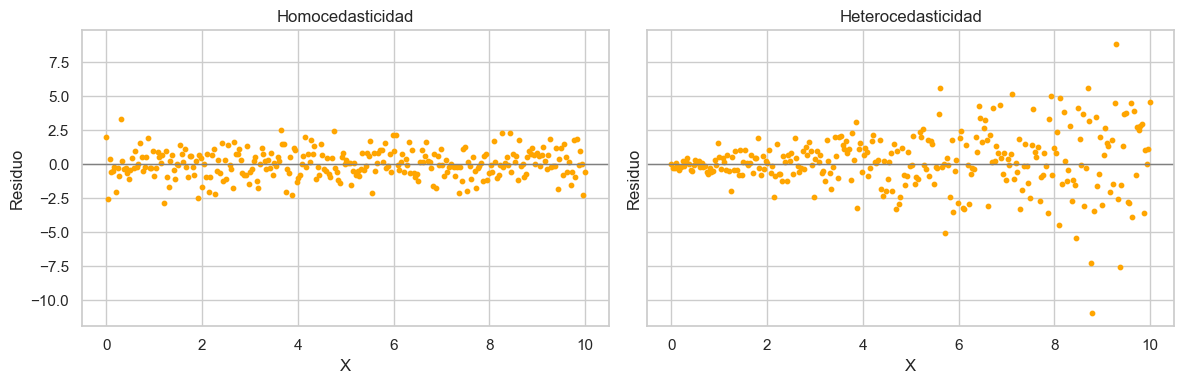

In [31]:
# Homocedasticidad (varianza constante) vs. heterocedasticidad (varianza creciente)
rng = default_rng(3)
n = 300
xh = np.linspace(0, 10, n)
res_homo   = rng.normal(0, 1.0, n)
res_hetero = rng.normal(0, 0.2 + 0.35 * xh, n)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
a1.scatter(xh, res_homo, s=10, color="orange");   a1.axhline(0, color="gray", lw=1)
a1.set_title("Homocedasticidad")
a2.scatter(xh, res_hetero, s=10, color="orange"); a2.axhline(0, color="gray", lw=1)
a2.set_title("Heterocedasticidad")
for a in (a1, a2): a.set_xlabel("X"); a.set_ylabel("Residuo")
plt.tight_layout()
plt.show()

## Supuestos de MCC para que los estimadores sean "buenos"

- **Ausencia de correlación serial entre errores.** $\operatorname{Cov}(\varepsilon_i, \varepsilon_h) = 0$. El error en una observación i no guarda relación con el de otra observación h.
- **No multicolinealidad.** No debe existir dependencia lineal entre variables explicativas. Por ejemplo: ingreso y salario.

La violación de estos supuestos produce que los estimadores de MCC no sean eficientes, consistentes e insesgados ("buenos"):

- **Eficiencia:** su varianza es la menor de entre todos los estimadores.
- **Consistencia:** a medida que aumenta el tamaño de la muestra, los estimadores de los parámetros se acercan a los valores de los parámetros poblacionales.
- **Insesgadez:** el valor del parámetro estimado por el modelo coincide con el valor del parámetro estimado. $E(\hat{\beta}) = \beta$.

## Supuestos de MCC para que los estimadores sean "buenos"

<figure style="text-align:center; margin:1em 0;">
  <img src="media/meme_multicolinealidad.png" width="380">
</figure>

## Estimación de una regresión lineal simple

Aplicamos el modelo al **Quality of Government (QoG) Basic dataset** (un país por fila).

¿Qué relación podemos esperar entre las siguientes variables?

- PBI per cápita (`wdi_gdpcapcon2015`, USD constantes de 2015).
- Nivel de democracia electoral (`vdem_polyarchy`, índice de poliarquía de V-Dem, de 0 a 1).

¿Cuál podría ser Y y cuál X?

In [32]:
qog = pd.read_stata("qog_bas_cs_jan26.dta", convert_categoricals=False)

datos = (qog[["cname", "wdi_gdpcapcon2015", "vdem_polyarchy"]]
         .rename(columns={"wdi_gdpcapcon2015": "pbi_pc", "vdem_polyarchy": "democracia"})
         .dropna())
print("Países con datos completos:", len(datos))
datos.head()

Países con datos completos: 167


,cname,pbi_pc,democracia
0,Afghanistan,377.665627,0.076
1,Albania,5867.650962,0.520
2,Algeria,4544.466881,0.267
4,Angola,2860.902519,0.327
6,Azerbaijan,5599.585250,0.185


Estimamos la correlación entre ambas variables y las graficamos. El PBI per cápita está muy sesgado (pocos países muy ricos), por lo que además tomamos su logaritmo, que suele usarse en estos casos.

In [33]:
datos["log_pbi"] = np.log(datos["pbi_pc"])
print("Correlación PBI (nivel) - democracia :", round(datos["pbi_pc"].corr(datos["democracia"]), 3))
print("Correlación log(PBI)    - democracia :", round(datos["log_pbi"].corr(datos["democracia"]), 3))

Correlación PBI (nivel) - democracia : 0.494
Correlación log(PBI)    - democracia : 0.536


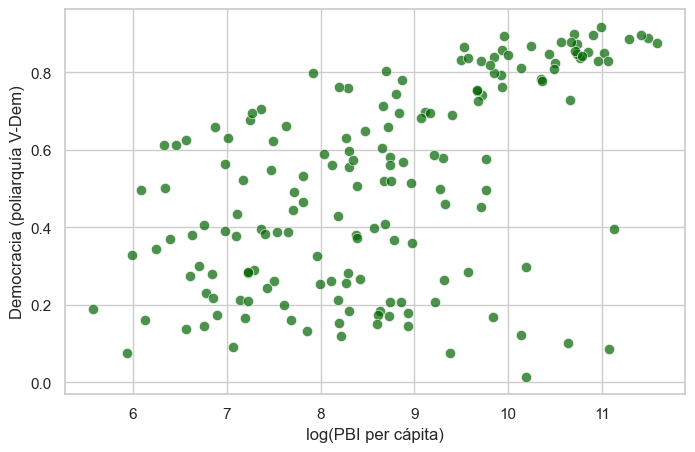

In [34]:
plt.figure()
sns.scatterplot(x=datos["log_pbi"], y=datos["democracia"], s=55, color="darkgreen", alpha=.7)
plt.xlabel("log(PBI per cápita)")
plt.ylabel("Democracia (poliarquía V-Dem)")
plt.show()

Estimamos el modelo por mínimos cuadrados (OLS). Recordar: el estimador de alfa es `const`, el estimador de beta acompaña al regresor, el estadístico t es = estimado / error estándar, y el p-value permite descartar (o no) que el estimador sea nulo. El R² indica qué medida de la varianza de Y es explicada por X.

In [35]:
X_q = sm.add_constant(datos["log_pbi"])
modelo = sm.OLS(datos["democracia"], X_q).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:             democracia   R-squared:                       0.287
Model:                            OLS   Adj. R-squared:                  0.283
Method:                 Least Squares   F-statistic:                     66.49
Date:                Mon, 20 Jul 2026   Prob (F-statistic):           8.43e-14
Time:                        18:27:46   Log-Likelihood:                 18.294
No. Observations:                 167   AIC:                            -32.59
Df Residuals:                     165   BIC:                            -26.35
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3208      0.104     -3.097      0.0

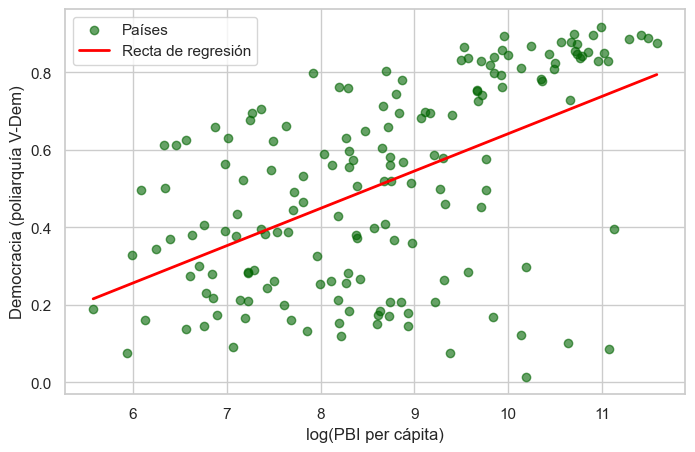

In [36]:
b0q, b1q = modelo.params
plt.figure()
plt.scatter(datos["log_pbi"], datos["democracia"], color="darkgreen", alpha=.6, label="Países")
xg = np.linspace(datos["log_pbi"].min(), datos["log_pbi"].max(), 100)
plt.plot(xg, b0q + b1q * xg, color="red", linewidth=2, label="Recta de regresión")
plt.xlabel("log(PBI per cápita)"); plt.ylabel("Democracia (poliarquía V-Dem)")
plt.legend()
plt.show()

El modelo de regresión propuesto solo sirve para estimar dentro del rango de valores propuestos en la muestra.